# HW#2-5: 지문 영상 개선

지문 영상(finger.jpg)의 품질을 개선한다.  
수업시간에 배운 방법(히스토그램 평활화)을 기본으로 적용하고, 추가 방법(CLAHE, 샤프닝)도 적용하여 비교한다.

Image shape: (238, 315), dtype: uint8


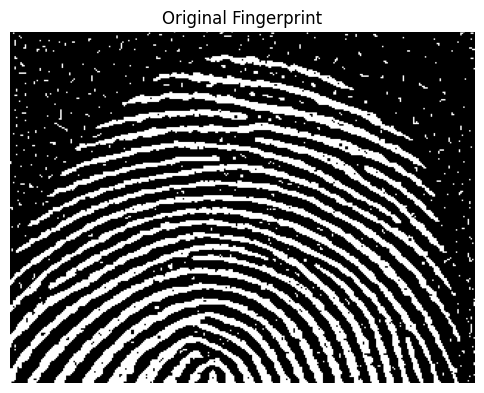

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 영상 로드
img = cv2.imread('data/finger.jpg', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Original Fingerprint')
plt.axis('off')
plt.show()

## 방법 1: 히스토그램 평활화 (Histogram Equalization)

전체 영상에 대해 히스토그램을 균일하게 분포시켜 대비를 개선한다.

/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_63671/1415745928.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 0].hist(img.ravel(), 256, [0, 256], color='gray')
/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_63671/1415745928.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(hist_eq.ravel(), 256, [0, 256], color='gray')


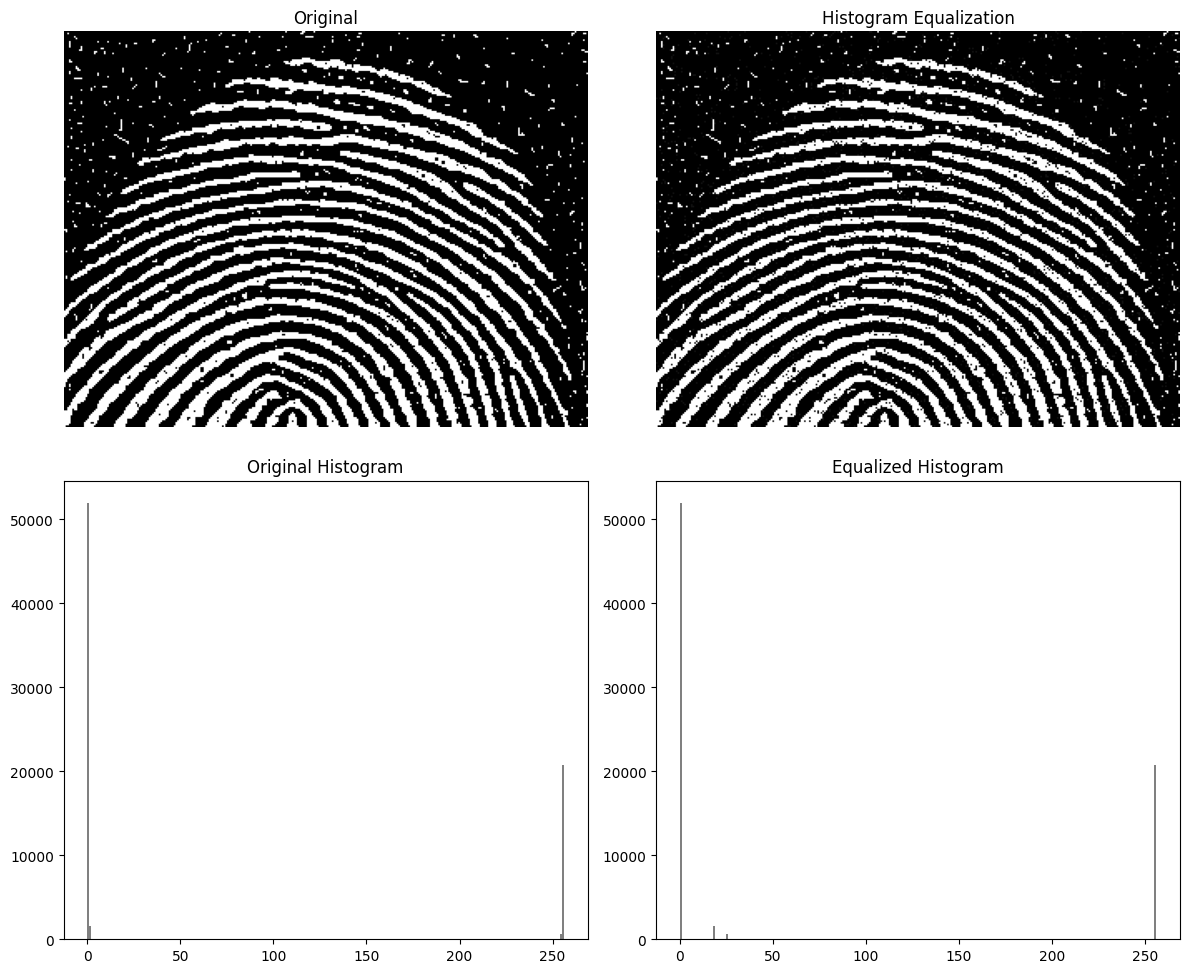

In [2]:
# 히스토그램 평활화
hist_eq = cv2.equalizeHist(img)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(hist_eq, cmap='gray')
axes[0, 1].set_title('Histogram Equalization')
axes[0, 1].axis('off')

axes[1, 0].hist(img.ravel(), 256, [0, 256], color='gray')
axes[1, 0].set_title('Original Histogram')

axes[1, 1].hist(hist_eq.ravel(), 256, [0, 256], color='gray')
axes[1, 1].set_title('Equalized Histogram')

plt.tight_layout()
plt.show()

## 방법 2: CLAHE (Contrast Limited Adaptive Histogram Equalization)

영상을 작은 블록으로 나누어 지역적으로 히스토그램 평활화를 수행한다.  
clipLimit으로 대비 증폭을 제한하여 노이즈 증폭을 억제한다.

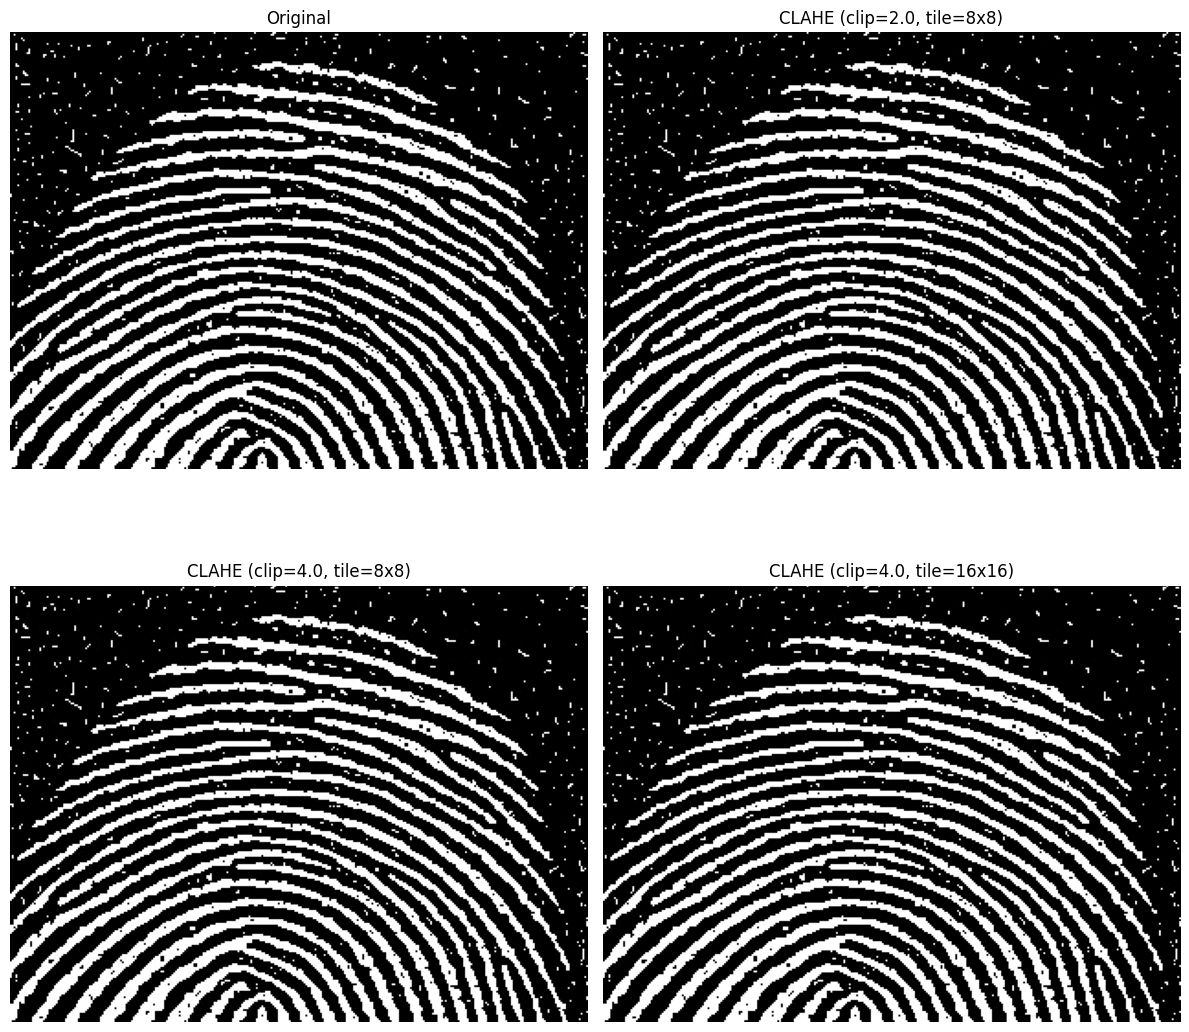

In [3]:
# CLAHE 적용 (다양한 파라미터)
clahe_1 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_2 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
clahe_3 = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(16, 16))

result_clahe_1 = clahe_1.apply(img)
result_clahe_2 = clahe_2.apply(img)
result_clahe_3 = clahe_3.apply(img)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(result_clahe_1, cmap='gray')
axes[0, 1].set_title('CLAHE (clip=2.0, tile=8x8)')
axes[0, 1].axis('off')

axes[1, 0].imshow(result_clahe_2, cmap='gray')
axes[1, 0].set_title('CLAHE (clip=4.0, tile=8x8)')
axes[1, 0].axis('off')

axes[1, 1].imshow(result_clahe_3, cmap='gray')
axes[1, 1].set_title('CLAHE (clip=4.0, tile=16x16)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## 방법 3: 샤프닝 (Unsharp Masking)

Gaussian blur로 저주파 성분을 추출한 뒤, 원본에서 빼서 고주파(edge) 성분을 강조한다.  
`sharpened = original + k * (original - blurred)`

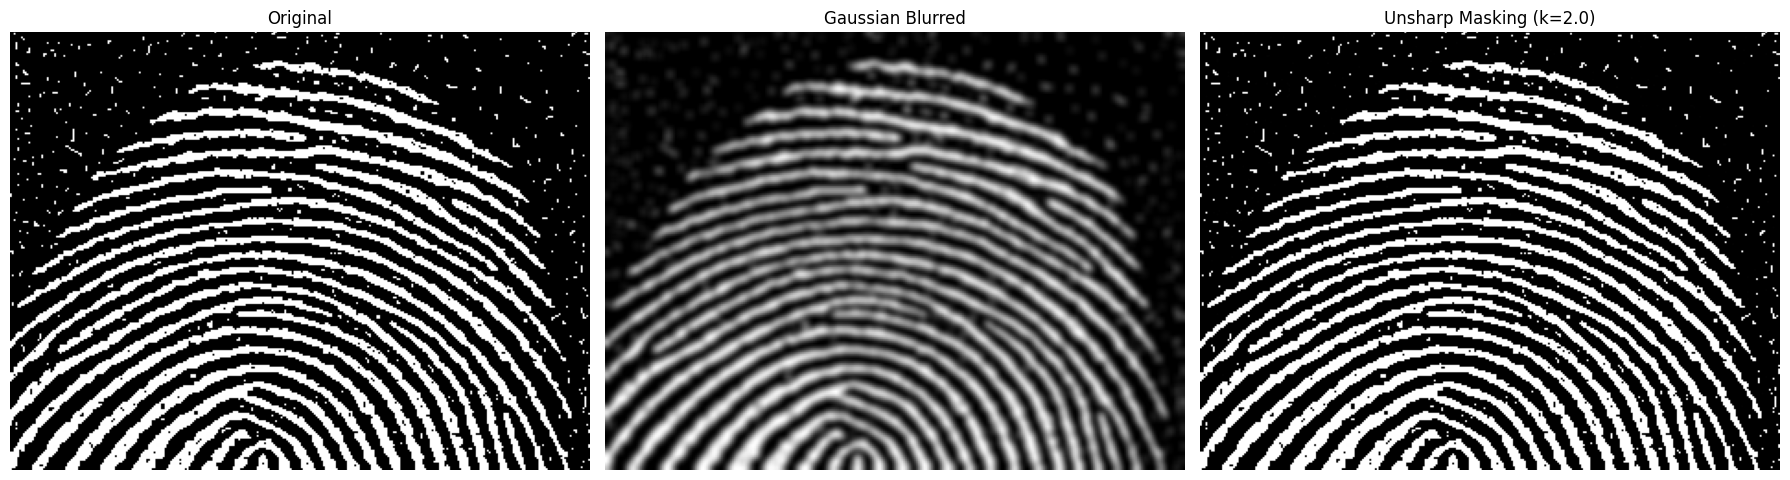

In [4]:
# Unsharp Masking
blurred = cv2.GaussianBlur(img, (7, 7), 2.0)
# k 값을 조절하여 샤프닝 강도 조절
k = 2.0
sharpened = cv2.addWeighted(img, 1 + k, blurred, -k, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(blurred, cmap='gray')
axes[1].set_title('Gaussian Blurred')
axes[1].axis('off')

axes[2].imshow(sharpened, cmap='gray')
axes[2].set_title(f'Unsharp Masking (k={k})')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 조합: CLAHE + Sharpening

CLAHE로 대비를 개선한 후, 샤프닝으로 지문 ridge를 더 선명하게 만든다.

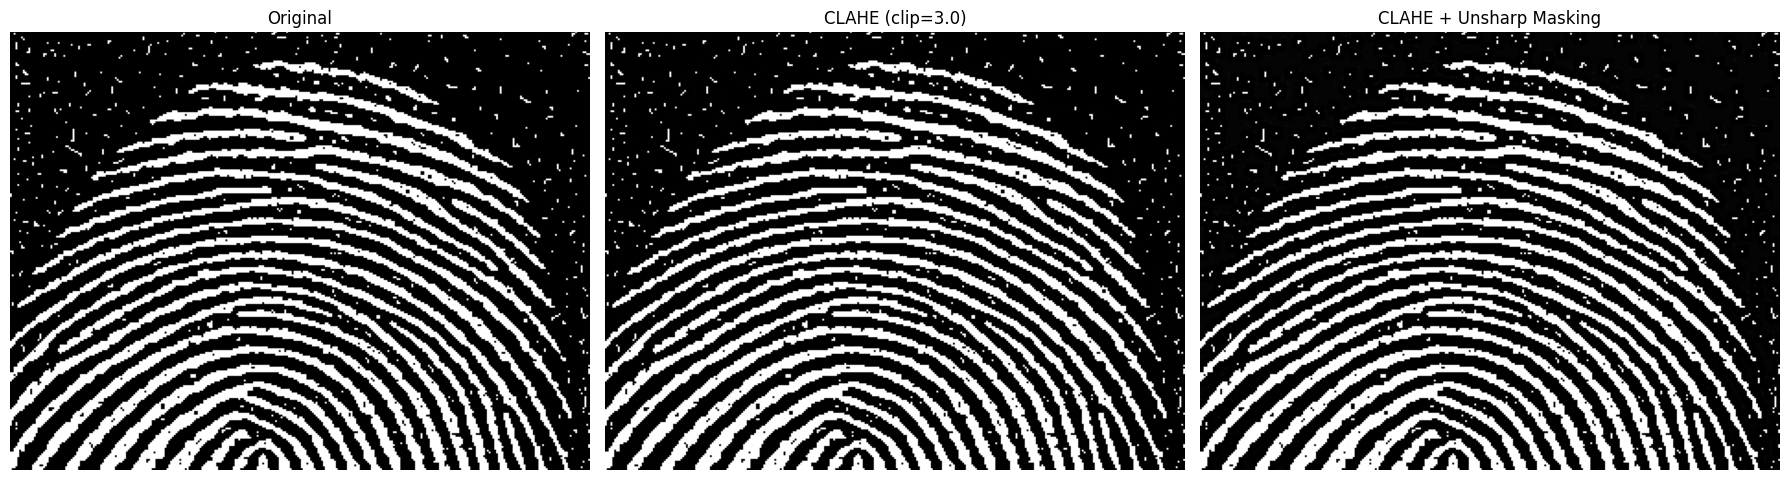

In [5]:
# CLAHE 먼저 적용 후 샤프닝
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced = clahe.apply(img)

blurred_e = cv2.GaussianBlur(enhanced, (7, 7), 2.0)
final = cv2.addWeighted(enhanced, 1 + 1.5, blurred_e, -1.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('CLAHE (clip=3.0)')
axes[1].axis('off')

axes[2].imshow(final, cmap='gray')
axes[2].set_title('CLAHE + Unsharp Masking')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_5_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 분석

**히스토그램 평활화:**  
전체적인 대비가 개선되지만, 전역적으로 적용되므로 지문의 밝은 영역과 어두운 영역의 지역적 특성을 충분히 반영하지 못한다. 노이즈도 함께 증폭될 수 있다.

**CLAHE:**  
지역적 대비 개선으로 지문의 ridge/valley 구조가 전체 영역에서 고르게 강조된다. clipLimit이 클수록 대비가 강해지지만 노이즈도 증가한다. tileGridSize가 클수록 더 넓은 영역을 고려한다.

**Unsharp Masking:**  
edge(ridge 경계)가 선명해지지만 대비 자체를 개선하지는 않는다.

**CLAHE + Sharpening 조합:**  
CLAHE로 대비를 먼저 개선하고, 샤프닝으로 ridge를 강조하면 원본 대비 가장 뚜렷한 지문 패턴을 얻을 수 있다. 과제에서 요구하는 개선 결과와 가장 유사하다.